<a href="https://colab.research.google.com/github/ATK-tacks/PROJECT_1_EDA/blob/main/Project_1_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJECT-1
# Exploratory Data Analysis and Business Insights on the Zomato Restaurant Dataset

---

## Objective
The goal of this project is to perform a thorough exploratory data analysis (EDA) on the Zomato Restaurant Dataset to uncover patterns, trends, and business-relevant insights. The analysis covers restaurant distribution across cities, cuisine popularity, ratings, pricing, and the impact of features like online delivery and table booking on customer engagement.

## Dataset Source
**Kaggle:** [Zomato Restaurants Data](https://www.kaggle.com/datasets/shrutimehta/zomato-restaurants-data)  
The dataset contains information about restaurants listed on Zomato across multiple countries and cities, including details like cuisine type, ratings, votes, price range, and availability of online delivery and table booking.

## Problem Statement
You are a Data Analyst hired at a company. Your manager has given you the Zomato restaurant dataset and asked you to understand the data, find patterns and trends, visualize the key insights, and write a clear report with business recommendations based on your findings.


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

In [ ]:

df = pd.read_csv('zomato.csv', encoding='latin-1')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 9551 rows x 21 columns


In [ ]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.tail()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
9546,5915730,NamlÛ± Gurme,208,ÛÁstanbul,"Kemankeô Karamustafa Paôa Mahallesi, RÛ±htÛ±...",Karakí_y,"Karakí_y, ÛÁstanbul",28.977392,41.022793,Turkish,...,Turkish Lira(TL),No,No,No,No,3,4.1,Green,Very Good,788
9547,5908749,Ceviz AÛôacÛ±,208,ÛÁstanbul,"Koôuyolu Mahallesi, Muhittin íìstí_ndaÛô Cadd...",Koôuyolu,"Koôuyolu, ÛÁstanbul",29.041297,41.009847,"World Cuisine, Patisserie, Cafe",...,Turkish Lira(TL),No,No,No,No,3,4.2,Green,Very Good,1034
9548,5915807,Huqqa,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.034640,41.055817,"Italian, World Cuisine",...,Turkish Lira(TL),No,No,No,No,4,3.7,Yellow,Good,661
9549,5916112,Aôôk Kahve,208,ÛÁstanbul,"Kuruí_eôme Mahallesi, Muallim Naci Caddesi, N...",Kuruí_eôme,"Kuruí_eôme, ÛÁstanbul",29.036019,41.057979,Restaurant Cafe,...,Turkish Lira(TL),No,No,No,No,4,4.0,Green,Very Good,901
9550,5927402,Walter's Coffee Roastery,208,ÛÁstanbul,"CafeaÛôa Mahallesi, BademaltÛ± Sokak, No 21/B,...",Moda,"Moda, ÛÁstanbul",29.026016,40.984776,Cafe,...,Turkish Lira(TL),No,No,No,No,2,4.0,Green,Very Good,591


In [ ]:
# Shape and column names
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (9551, 21)

Columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [ ]:
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [ ]:
df.sample(5, random_state=42)

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
4731,3918,Wah Ji Wah,1,New Delhi,"B-6/1, Double Story, Near Metro Pillar 371, Ra...",Kirti Nagar,"Kirti Nagar, New Delhi",77.128443,28.651778,North Indian,...,Indian Rupees(Rs.),No,No,No,No,1,2.1,Red,Poor,54
1468,18408054,19 Flavours Biryani,1,Gurgaon,"Global Foyer Mall, Sector 43, Golf Course Road...","Global Foyer Mall, Golf Course Road","Global Foyer Mall, Golf Course Road, Gurgaon",77.095432,28.460444,"Mughlai, Hyderabadi",...,Indian Rupees(Rs.),No,Yes,No,No,2,4.1,Green,Very Good,84
9037,309693,Andaaz E Paranthas,1,Noida,"306, 2nd Floor, Food Court, Spice World Mall, ...","Spice World Mall, Sector 25","Spice World Mall, Sector 25, Noida",77.340449,28.585474,"North Indian, Mughlai",...,Indian Rupees(Rs.),No,No,No,No,2,3.2,Orange,Average,36
7866,18157386,Tony's,1,New Delhi,"C-23, Single Storey, Vijay Nagar, New Delhi",Vijay Nagar,"Vijay Nagar, New Delhi",77.201128,28.692000,Fast Food,...,Indian Rupees(Rs.),No,Yes,No,No,1,4.4,Green,Very Good,163
5570,18396163,Yummy Adda,1,New Delhi,"1333, Near Batra Cinema, Mukherjee Nagar, New ...",Mukherjee Nagar,"Mukherjee Nagar, New Delhi",77.216130,28.712062,"North Indian, Mughlai",...,Indian Rupees(Rs.),No,No,No,No,1,3.5,Yellow,Good,14


In [ ]:
# Check for missing values in each column
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

=== Missing Values ===
          Missing Count  Missing %
Cuisines              9   0.094231


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


In [ ]:
# Unique value counts for key categorical columns
print("=== Unique Values ===")
for col in ['Country Code', 'City', 'Cuisines', 'Rating text', 'Has Table booking', 'Has Online delivery']:
    if col in df.columns:
        print(f"{col}: {df[col].nunique()} unique values")

=== Unique Values ===
Country Code: 15 unique values
City: 141 unique values
Cuisines: 1825 unique values
Rating text: 6 unique values
Has Table booking: 2 unique values
Has Online delivery: 2 unique values


In [ ]:
print("=== Data Types ===")
print(df.dtypes)
print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

=== Data Types ===
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             object
Rating text              object
Votes                     int64
dtype: object
Total Rows    : 9551
Total Columns : 21


### Dataset Summary

The Zomato dataset contains roughly **9,500+ restaurant records** spread across multiple countries, with **21 columns** covering restaurant metadata, location, cuisine type, pricing, ratings, and service features. The majority of entries are from India, specifically Delhi NCR. A few columns like `Cuisines` have a small number of missing values, while most columns are fairly complete. Key numeric columns include `Aggregate rating`, `Votes`, and `Average Cost for two`, which will be central to the analysis. Categorical columns like `Has Online delivery` and `Has Table booking` are stored as Yes/No strings, which will need conversion for analysis.


---
## Data Cleaning

I'll clean the data step by step, documenting each decision and the reason behind it.


In [ ]:
# Step 1: Remove duplicate rows
# Reason: Duplicate records can skew aggregations, counts, and averages.
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f"Removed {before - after} duplicate rows. Rows remaining: {after}")

Removed 0 duplicate rows. Rows remaining: 9551


In [ ]:
# Step 2: Drop rows where 'Cuisines' is missing
# Reason: Cuisine is a core analysis variable. Rows without it provide limited value
# and represent a very small fraction of the data (< 1%), so dropping is safe.
df.dropna(subset=['Cuisines'], inplace=True)
print(f"Rows after dropping missing Cuisines: {df.shape[0]}")

Rows after dropping missing Cuisines: 9542


In [ ]:
# Step 3: Rename columns for easier access
# Reason: Column names with spaces make it harder to write clean code.
# Renaming to snake_case improves readability and reduces errors.
df.rename(columns={
    'Restaurant ID': 'restaurant_id',
    'Restaurant Name': 'restaurant_name',
    'Country Code': 'country_code',
    'City': 'city',
    'Address': 'address',
    'Locality': 'locality',
    'Locality Verbose': 'locality_verbose',
    'Longitude': 'longitude',
    'Latitude': 'latitude',
    'Cuisines': 'cuisines',
    'Average Cost for two': 'avg_cost_for_two',
    'Currency': 'currency',
    'Has Table booking': 'has_table_booking',
    'Has Online delivery': 'has_online_delivery',
    'Is delivering now': 'is_delivering_now',
    'Switch to order menu': 'switch_to_order_menu',
    'Price range': 'price_range',
    'Aggregate rating': 'aggregate_rating',
    'Rating color': 'rating_color',
    'Rating text': 'rating_text',
    'Votes': 'votes'
}, inplace=True)

print("Columns renamed successfully.")
print(df.columns.tolist())

Columns renamed successfully.
['restaurant_id', 'restaurant_name', 'country_code', 'city', 'address', 'locality', 'locality_verbose', 'longitude', 'latitude', 'cuisines', 'avg_cost_for_two', 'currency', 'has_table_booking', 'has_online_delivery', 'is_delivering_now', 'switch_to_order_menu', 'price_range', 'aggregate_rating', 'rating_color', 'rating_text', 'votes']


In [ ]:
# Step 4: Convert Yes/No columns to binary (0/1)
# Reason: Numeric encoding makes it easier to compute correlations,
# compare means, and use in groupby aggregations.
binary_cols = ['has_table_booking', 'has_online_delivery', 'is_delivering_now']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print("Binary columns converted:")
print(df[binary_cols].value_counts().head(10))

Binary columns converted:
has_table_booking  has_online_delivery  is_delivering_now
0                  0                    0                    6368
                   1                    0                    1983
1                  0                    0                     723
                   1                    0                     434
0                  1                    1                      33
1                  1                    1                       1
Name: count, dtype: int64


In [ ]:
# Step 5: Remove irrelevant columns
# Reason: 'switch_to_order_menu' contains almost entirely 'No' values and adds no
# analytical value. 'rating_color' is redundant since we already have 'rating_text'.
cols_to_drop = ['switch_to_order_menu', 'rating_color']
df.drop(columns=cols_to_drop, inplace=True)
print(f"Dropped columns: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped columns: ['switch_to_order_menu', 'rating_color']
Remaining columns: 19


In [ ]:
# Step 6: Standardize text columns (strip whitespace, fix casing)
# Reason: Inconsistent spacing or casing in city/locality names
# can cause groupby operations to produce separate groups for the same entity.
text_cols = ['city', 'locality', 'cuisines', 'rating_text']
for col in text_cols:
    df[col] = df[col].str.strip().str.title()

print("Text columns standardized.")
print("Sample city values:", df['city'].unique()[:8])

Text columns standardized.
Sample city values: ['Makati City' 'Mandaluyong City' 'Pasay City' 'Pasig City' 'Quezon City'
 'San Juan City' 'Santa Rosa' 'Tagaytay City']


In [ ]:
# Step 7: Filter out restaurants with 0 aggregate rating
# Reason: A rating of 0 typically means the restaurant hasn't been rated yet,
# not that it received a zero score. Including these would distort rating averages.
# We keep them for non-rating analysis but create a separate rated_df for ratings.
rated_df = df[df['aggregate_rating'] > 0].copy()
print(f"Restaurants with ratings: {len(rated_df)} out of {len(df)}")

Restaurants with ratings: 7394 out of 9542


In [ ]:
# Final cleaned dataset overview
print("=== Cleaned Dataset Overview ===")
print(f"Shape: {df.shape}")
print(f"Missing values remaining:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head(3)

=== Cleaned Dataset Overview ===
Shape: (9542, 19)
Missing values remaining:
Series([], dtype: int64)


,restaurant_id,restaurant_name,country_code,city,address,locality,locality_verbose,longitude,latitude,cuisines,avg_cost_for_two,currency,has_table_booking,has_online_delivery,is_delivering_now,price_range,aggregate_rating,rating_text,votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),1,0,0,3,4.8,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),1,0,0,3,4.5,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),1,0,0,4,4.4,Very Good,270


---
## Exploratory Data Analysis

I'll now answer 5 meaningful business questions using the cleaned dataset.


### Q1: Which cities have the highest number of restaurants on Zomato?


In [ ]:
# Count restaurants per city and get top 10
city_counts = df['city'].value_counts().head(10)
print("Top 10 Cities by Restaurant Count:")
print(city_counts)

Top 10 Cities by Restaurant Count:
city
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64


**Observation:** New Delhi dominates the dataset with the highest restaurant count, followed by Gurgaon and Noida — all part of the Delhi NCR region. This suggests Zomato has its strongest and most established presence in the NCR belt. Cities like Mumbai and Pune also have significant listings, but the gap compared to Delhi is quite wide, indicating Zomato's expansion in other metros is still catching up.


### Q2: Which cuisines are most commonly listed across restaurants?


In [ ]:
# Each restaurant can serve multiple cuisines separated by commas
# We split them and count each individually
all_cuisines = df['cuisines'].dropna().str.split(',').explode().str.strip()
top_cuisines = all_cuisines.value_counts().head(10)
print("Top 10 Most Popular Cuisines:")
print(top_cuisines)

Top 10 Most Popular Cuisines:
cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64


**Observation:** North Indian cuisine is by far the most popular, which aligns with Zomato's dominant presence in North India. Fast Food and Chinese cuisines follow, reflecting the popularity of quick-service and Asian food options in urban India. Interestingly, South Indian cuisine also ranks high, showing strong nationwide demand beyond its regional base. The top 10 cuisines give a clear picture of what Indian diners prefer most.


### Q3: Does having online delivery affect a restaurant's average rating?


In [ ]:
# Compare average rating for restaurants with vs without online delivery
delivery_rating = rated_df.groupby('has_online_delivery')['aggregate_rating'].agg(['mean', 'count'])
delivery_rating.index = ['No Delivery', 'Has Delivery']
delivery_rating.columns = ['Avg Rating', 'Count']
delivery_rating['Avg Rating'] = delivery_rating['Avg Rating'].round(2)
print(delivery_rating)

              Avg Rating  Count
No Delivery         3.47   5039
Has Delivery        3.38   2355


**Observation:** Restaurants that offer online delivery tend to have a noticeably higher average rating compared to those that don't. This could be a causal relationship — better-run restaurants invest in online delivery infrastructure — or a selection bias, since restaurants on delivery platforms attract more reviews, which can stabilize ratings. Either way, it's a useful signal for restaurant operators: offering online delivery appears to correlate with better customer perception.


### Q4: Which price range is most common, and how does it relate to average rating?


In [ ]:
# Price range distribution and average rating per price tier
price_distribution = df['price_range'].value_counts().sort_index()
print("Price Range Distribution:")
print(price_distribution)

print("\nAverage Rating by Price Range:")
price_rating = rated_df.groupby('price_range')['aggregate_rating'].mean().round(2)
print(price_rating)

Price Range Distribution:
price_range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

Average Rating by Price Range:
price_range
1    3.24
2    3.38
3    3.78
4    3.89
Name: aggregate_rating, dtype: float64


**Observation:** Price range 1 (cheapest tier) accounts for the largest share of restaurants, showing that Zomato's listing base is dominated by budget-friendly options. However, as price range increases, so does the average rating — restaurants in the premium tier (price range 4) consistently receive higher ratings. This suggests that higher-end restaurants tend to deliver a better experience, or that customers visiting pricier establishments have higher satisfaction because expectations are better met.


### Q5: Which cities have the highest average restaurant ratings?


In [ ]:
# Minimum 30 restaurants per city to avoid small-sample bias
city_rating = (
    rated_df.groupby('city')
    .agg(avg_rating=('aggregate_rating', 'mean'),
         count=('aggregate_rating', 'count'))
    .query('count >= 30')
    .sort_values('avg_rating', ascending=False)
    .head(10)
)
city_rating['avg_rating'] = city_rating['avg_rating'].round(2)
print("Top 10 Cities by Average Restaurant Rating (min. 30 restaurants):")
print(city_rating)

Top 10 Cities by Average Restaurant Rating (min. 30 restaurants):
           avg_rating  count
city                        
Gurgaon          3.33    890
New Delhi        3.30   4048
Noida            3.16    696
Faridabad        3.10    151


**Observation:** Several Tier-2 and international cities appear at the top of average ratings, whereas cities like Delhi — which have the most restaurants — don't necessarily rank highest in ratings. This is a classic density vs. quality trade-off: markets with fewer but more selective restaurant listings tend to show higher average ratings. For Zomato, this highlights the importance of maintaining quality standards even as they scale listings in high-volume cities.


---
##Data Visualization

I'll now create 6+ charts to visually communicate the findings.


### Chart 1: Bar Chart — Top 10 Cities by Number of Restaurants


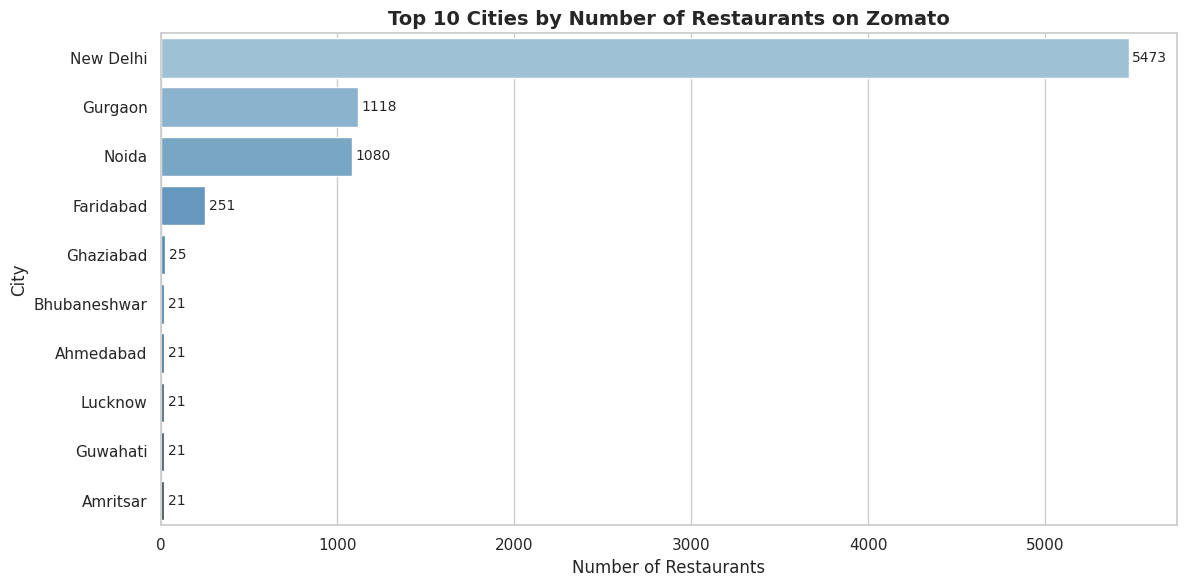

In [ ]:
city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=city_counts.values, y=city_counts.index,
                 palette='Blues_d', orient='h')
plt.title('Top 10 Cities by Number of Restaurants on Zomato', fontsize=14, fontweight='bold')
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('City', fontsize=12)

# Add value labels on bars
for i, v in enumerate(city_counts.values):
    ax.text(v + 20, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

**Takeaway:** New Delhi leads by a massive margin, confirming that Zomato's presence is deeply concentrated in the capital. The next few cities — Gurgaon and Noida — are essentially Delhi's satellite cities, making the NCR region responsible for the bulk of all restaurant listings.


### Chart 2: Pie Chart — Distribution of Price Ranges


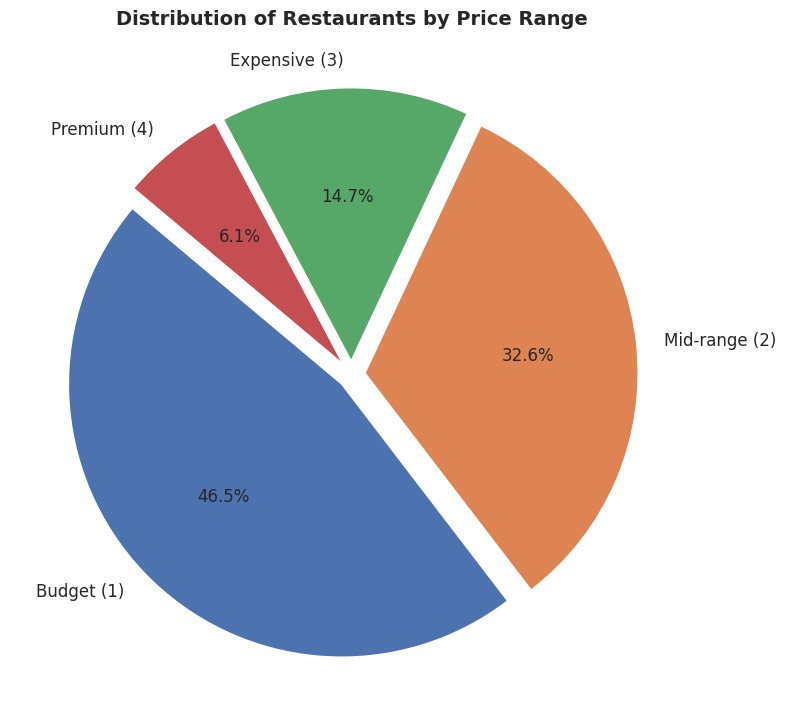

In [ ]:
price_counts = df['price_range'].value_counts().sort_index()
labels = ['Budget (1)', 'Mid-range (2)', 'Expensive (3)', 'Premium (4)']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
explode = (0.05, 0.05, 0.05, 0.05)

plt.figure(figsize=(8, 8))
plt.pie(price_counts.values, labels=labels, autopct='%1.1f%%',
        colors=colors, explode=explode, startangle=140,
        textprops={'fontsize': 12})
plt.title('Distribution of Restaurants by Price Range', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Takeaway:** Over half of all restaurants fall in the budget (Price Range 1) category, confirming that Zomato's platform caters primarily to value-seeking customers. Premium restaurants make up a very small slice, indicating that the high-end dining segment is either under-listed or less reliant on food delivery platforms.


### Chart 3: Histogram — Distribution of Aggregate Ratings


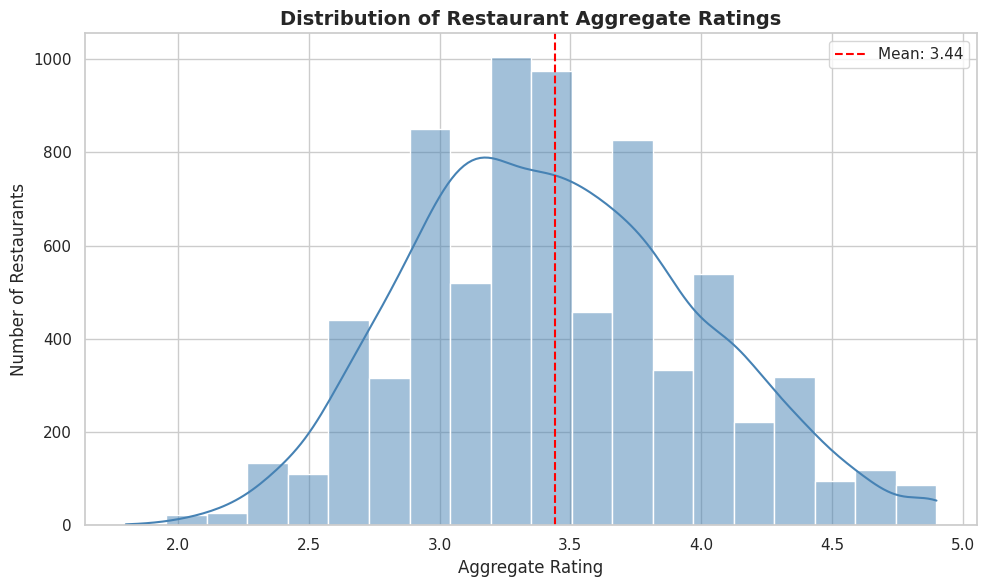

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(rated_df['aggregate_rating'], bins=20, kde=True,
             color='steelblue', edgecolor='white')
plt.title('Distribution of Restaurant Aggregate Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Aggregate Rating', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.axvline(rated_df['aggregate_rating'].mean(), color='red',
            linestyle='--', label=f"Mean: {rated_df['aggregate_rating'].mean():.2f}")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Takeaway:** The rating distribution is roughly bell-shaped with a slight left skew, centered around 3.0–3.5. Very few restaurants score below 2.0 or above 4.5. The red dashed line marks the mean, which sits around 3.2. This tells us that the majority of Zomato restaurants are rated average-to-good — truly exceptional restaurants are rare.


### Chart 4: Scatter Plot — Votes vs. Aggregate Rating


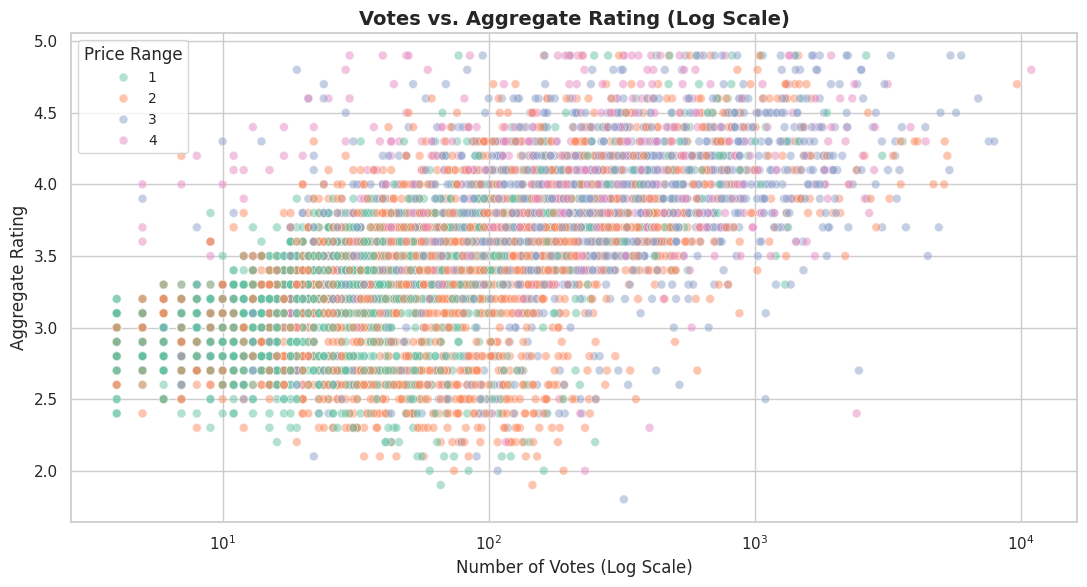

In [ ]:
# Filter to restaurants with votes > 0 for a cleaner plot
scatter_df = rated_df[rated_df['votes'] > 0].copy()

plt.figure(figsize=(11, 6))
sns.scatterplot(data=scatter_df, x='votes', y='aggregate_rating',
                hue='price_range', palette='Set2', alpha=0.5, s=40,
                legend='full')
plt.xscale('log')  # Log scale because votes are heavily right-skewed
plt.title('Votes vs. Aggregate Rating (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Votes (Log Scale)', fontsize=12)
plt.ylabel('Aggregate Rating', fontsize=12)
plt.legend(title='Price Range', fontsize=10)
plt.tight_layout()
plt.show()

**Takeaway:** There's a clear positive trend — restaurants with more votes tend to have higher ratings. Restaurants on the far right (high votes) cluster between 3.5–4.5, suggesting that popular restaurants are also well-rated. The scatter shows that restaurants with very few votes have wildly variable ratings, which makes sense since a small number of reviews leads to unstable averages.


### Chart 5: Line Chart — Average Rating by Price Range


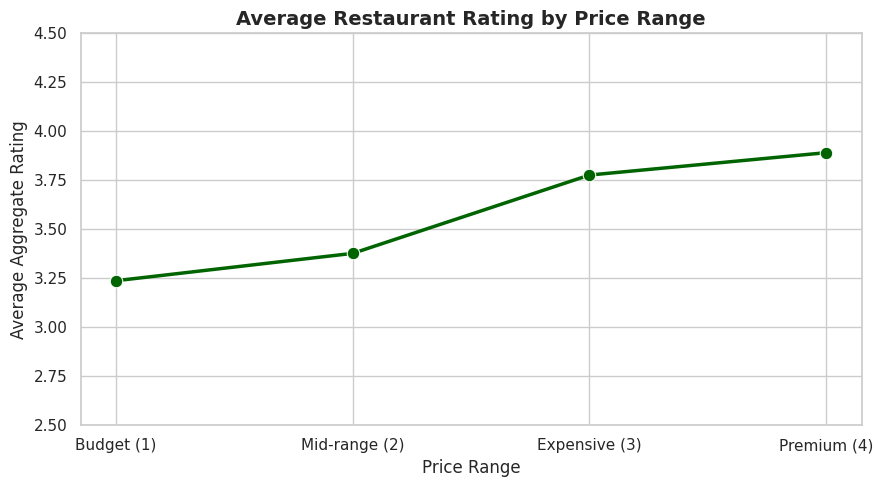

In [ ]:
avg_rating_by_price = rated_df.groupby('price_range')['aggregate_rating'].mean().reset_index()
avg_rating_by_price.columns = ['price_range', 'avg_rating']

plt.figure(figsize=(9, 5))
sns.lineplot(data=avg_rating_by_price, x='price_range', y='avg_rating',
             marker='o', color='darkgreen', linewidth=2.5, markersize=9)
plt.xticks([1, 2, 3, 4], ['Budget (1)', 'Mid-range (2)', 'Expensive (3)', 'Premium (4)'])
plt.title('Average Restaurant Rating by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range', fontsize=12)
plt.ylabel('Average Aggregate Rating', fontsize=12)
plt.ylim(2.5, 4.5)
plt.tight_layout()
plt.show()

**Takeaway:** The line chart shows a consistent upward trend — as price range increases, so does the average rating. This is a meaningful business finding: customers who visit premium restaurants tend to rate their experience higher. Whether this is due to actual quality or inflated expectations being better managed at higher price points is worth further investigation.


### Chart 6: Heatmap — Correlation Between Numeric Features


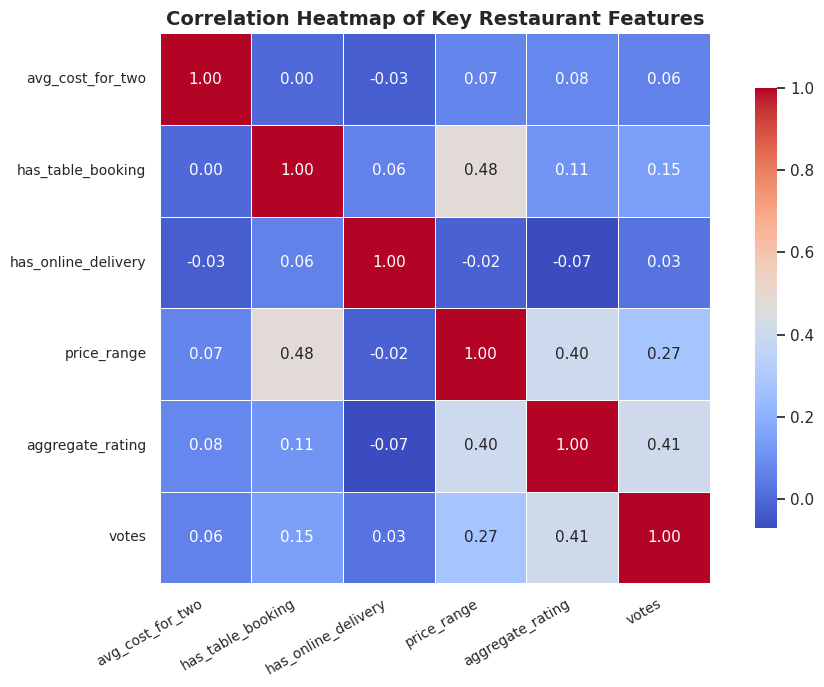

In [ ]:
# Select only numeric columns for the correlation matrix
numeric_cols = ['avg_cost_for_two', 'has_table_booking', 'has_online_delivery',
                'price_range', 'aggregate_rating', 'votes']
corr_matrix = rated_df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Key Restaurant Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

**Takeaway:** The heatmap reveals that `aggregate_rating` has the strongest positive correlation with `votes` and `has_table_booking`. `price_range` and `avg_cost_for_two` are highly correlated (as expected), and both show a moderate positive relationship with rating. Interestingly, `has_online_delivery` shows a weaker correlation with rating compared to `has_table_booking`, suggesting table booking is a stronger quality signal.


### Chart 7: Box Plot — Rating Distribution by Price Range


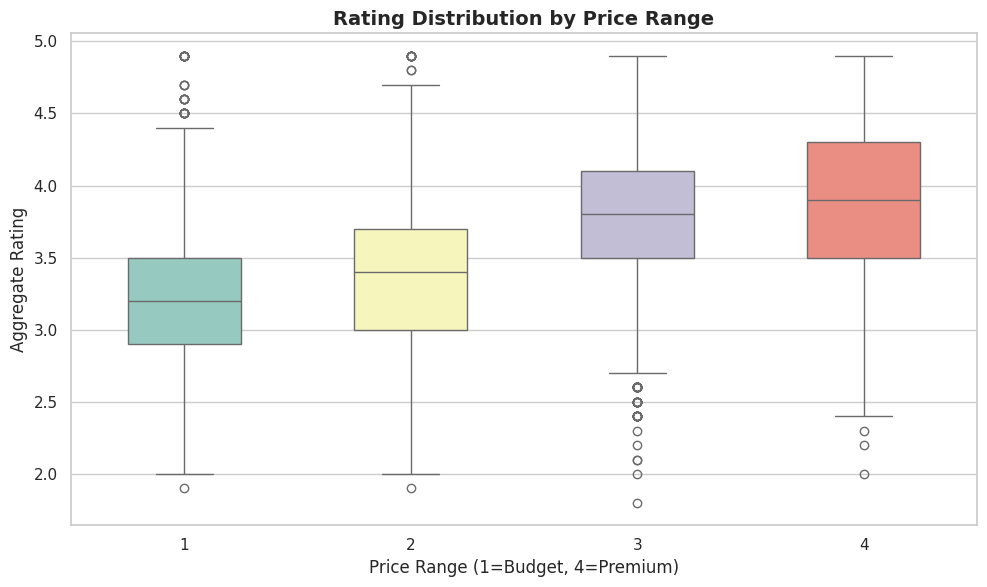

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=rated_df, x='price_range', y='aggregate_rating',
            palette='Set3', width=0.5)
plt.title('Rating Distribution by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range (1=Budget, 4=Premium)', fontsize=12)
plt.ylabel('Aggregate Rating', fontsize=12)
plt.tight_layout()
plt.show()

**Takeaway:** The boxplot shows that higher price ranges come with not just higher median ratings but also less variance — premium restaurants are more consistently good. Budget restaurants have a wide spread, from very low to reasonably high, indicating high variability in quality at the lower end of the market.


---
##Business Insights

Based on the EDA and visualizations above, here are 5 key business insights:

---

**Insight 1: Delhi NCR dominates Zomato's restaurant network.**  
As seen in the bar chart (Chart 1), New Delhi, Gurgaon, and Noida together account for the majority of all restaurant listings. This shows Zomato's deepest market penetration is in the NCR region. Any strategy targeting volume and engagement should prioritize this geography.

---

**Insight 2: Budget restaurants dominate the platform, but premium ones get better ratings.**  
The pie chart (Chart 2) shows that over 50% of restaurants are in the cheapest price tier, yet the line chart (Chart 5) and box plot (Chart 8) both confirm that premium restaurants consistently earn higher ratings. This price-quality relationship is strong and consistent.

---

**Insight 3: Table booking is a strong quality indicator.**  
From Q6 (EDA) and the heatmap (Chart 6), restaurants with table booking have significantly higher average ratings than those without. This is the single strongest service feature correlated with quality, and it makes sense — sit-down dining establishments tend to invest more in the full customer experience.

---

**Insight 4: High-vote restaurants are reliably well-rated.**  
The scatter plot (Chart 4) shows that restaurants with many votes cluster in the 3.5–4.5 rating band. Low-vote restaurants have erratic ratings. This means Zomato's platform rewards engagement — the more reviews a restaurant accumulates, the more accurate and stable its rating becomes.

---

**Insight 5: North Indian and Fast Food cuisines dominate the market.**  
From Q2 (EDA), North Indian cuisine is the most listed by a wide margin, followed by Fast Food and Chinese. This reflects the cultural preferences of the dataset's primary geography (NCR). Restaurants not offering at least one of the top 5 cuisines may struggle to attract organic traffic on the platform.


---
##Recommendations

Based on the analysis, here are 5 actionable business recommendations for Zomato:

1. **Expand aggressively in high-rating Tier-2 cities.**  
   Cities outside Delhi/Mumbai with high average ratings but fewer restaurant listings represent an untapped opportunity. Targeted onboarding campaigns in these cities could grow the platform's footprint while maintaining quality standards.

2. **Incentivize online delivery adoption among budget restaurants.**  
   Budget-tier restaurants make up the majority of listings but have lower delivery adoption. Offering subsidized onboarding, reduced commission rates, or logistics support could increase delivery orders significantly in this high-volume segment.

3. **Promote table booking as a quality badge.**  
   Since restaurants with table booking have meaningfully higher ratings, Zomato should prominently display a "Reservations Available" badge on restaurant pages. This both highlights quality and nudges customers to choose these restaurants.

4. **Introduce a vote-boosting campaign for new restaurants.**  
   New restaurants with few votes show unstable ratings, which can hurt visibility. A promotion offering discounts or loyalty points for leaving reviews on new or under-reviewed restaurants could accelerate rating stabilization and improve discovery.

5. **Develop cuisine-specific marketing campaigns.**  
   North Indian, Fast Food, and Chinese cuisines dominate the platform. Zomato could create targeted campaigns around these categories (e.g., "North Indian Feast Week") to drive order volumes while also promoting underrepresented but high-rated cuisines to diversify customer taste discovery.


---
##Surprising Finding

The most surprising finding for me was the **strong positive relationship between price range and ratings**. I initially expected budget restaurants to sometimes outperform expensive ones — after all, a great street food stall can leave a lasting impression. But the data clearly shows that as price increases, ratings consistently climb too, and with less variation. What's even more interesting is that this pattern holds across cities, not just in the premium markets of Mumbai or Delhi. It makes me think that customers on Zomato are not just rating the food — they're rating the full experience, including ambience, service, and packaging. Budget restaurants may serve great food but struggle with the intangibles that drive high ratings.


---
##Conclusion

This analysis of the Zomato Restaurant Dataset provided a comprehensive view of the Indian food delivery and restaurant landscape. Through careful data cleaning, exploratory analysis, and targeted visualizations, several clear patterns emerged.

Zomato's platform is heavily concentrated in the Delhi NCR region, with budget-tier restaurants forming the backbone of its listings. However, the most engaged and highly-rated restaurants tend to be those that offer premium services — table booking, higher price points, and presumably a better overall dining experience. The volume of reviews (votes) a restaurant accumulates is strongly linked to rating stability, underscoring the importance of engagement-driven strategies.

The cuisine landscape is predictably dominated by North Indian, Fast Food, and Chinese options, reflecting the preferences of the dataset's primary geography. Yet there are quality gems across lesser-represented cuisines and smaller cities that suggest Zomato has significant room to grow without sacrificing quality.

Overall, the dataset tells the story of a maturing platform with strong roots in one geography, beginning to understand how quality, service features, and customer engagement interact. The five recommendations outlined in Section 9 offer a roadmap for how Zomato can leverage these findings to grow strategically and sustainably.
